# Financial Modelling: Emotion-Enhanced ARX with Lag and Lead Features

This notebook extends the baseline ARX model by incorporating emotion/social indices with **both lag and lead features**:

- **AR lags**: Past returns of the target asset
- **Macro-financial controls**: EUR/USD, USD/CNY exchange rates, oil prices, 10Y Treasury yield (lags only)
- **Emotion indices with lags AND leads**: 7 emotion index families with heterogeneous lag and lead orders

## Lag vs Lead Features

**Lag Features (Past Values):**
- X(t-k) → Y(t+1): Past index values predict future returns
- Standard causal interpretation: social signals influence market behavior

**Lead Features (Future Values):**
- X(t+k) → Y(t+1): Future index values predict current returns
- Interpretations:
  1. **Anticipatory signals**: Forward-looking social media discourse
  2. **Reverse causality**: Returns precede social media response
  3. **Common factors**: Latent variables affecting both simultaneously

**Critical Note**: Lead features must be available at prediction time to avoid lookahead bias. Out-of-sample validation explicitly checks this.

**Optimization Strategy**: Lag and lead ranges both start from 0, allowing Optuna to discover lag-only, lead-only, or mixed specifications for each index family.

In [1]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [2]:
# Import custom modules
from modules.finance.models.arx import (
    LagSpec, 
    automl_group_arx, 
    make_group_arx_supervised,
    INDEX_FAMILIES
)
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    diebold_mariano_test,
    permutation_importance_cv,
    get_significance_stars
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_model_comparison_bars
)

print("Modules imported successfully")
print(f"\nEmotion index families: {list(INDEX_FAMILIES.keys())}")

Modules imported successfully

Emotion index families: ['ei', 'epi', 'epi_signed', 'ccd', 'intensity', 'surprise', 'split']


## Load Data

Load financial returns and emotion indices. The emotion indices include all 7 families with 4 weighting variants each.

In [3]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Load emotion data from epi_data.json
import json
with open(DATA_DIR / 'epi_data.json', 'r') as f:
    epi_data = json.load(f)

epi_df = pd.DataFrame(epi_data)
epi_df['date'] = pd.to_datetime(epi_df['date'])
epi_df = epi_df.set_index('date').sort_index()

print(f"Financial data shape: {df.shape}")
print(f"Emotion data shape: {epi_df.shape}")

# Join emotion data with financial data
df = df.join(epi_df, how='left')
print(f"Joined data shape: {df.shape}")

# Define columns
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Identify emotion index columns (all columns from epi_df)
emotion_cols = [col for col in epi_df.columns if col not in ['date']]
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"\nTarget columns: {TARGET_COLS}")
print(f"Control columns: {CONTROL_COLS}")
print(f"Emotion index columns: {len(emotion_cols)}")
print(f"\nEmotion columns: {emotion_cols}")

Financial data shape: (104, 44)
Emotion data shape: (148, 27)
Joined data shape: (104, 71)

Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00

Target columns: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
Control columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
Emotion index columns: 27

Emotion columns: ['ccd', 'ccd_engweighted', 'ccd_engweighted_topicweighted', 'ccd_topicweighted', 'ei_community', 'ei_community_topicweighted', 'ei_creator', 'ei_creator_engweighted', 'ei_creator_engweighted_topicweighted', 'ei_creator_topicweighted', 'epi', 'epi_engweighted', 'epi_engweighted_topicweighted', 'epi_signed', 'epi_signed_engweighted', 'epi_signed_engweighted_topicweighted', 'epi_signed_topicweighted', 'epi_topicweighted', 'intensity', 'intensity_engweighted', 'intensity_engweighted_topicweighted', 'intensity_topicweighted', 'split', 'surprise', 'surprise_engweighted', 'surprise_engweighted_topicweighted', 'surprise_topicweigh

In [4]:
# Prepare clean dataset
df_clean = df.dropna(subset=TARGET_COLS)

# Fill emotion columns with 0 if missing
for col in emotion_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print(f"Clean data shape: {df_clean.shape}")
print(f"\nMissing values in emotion columns: {df_clean[emotion_cols].isna().sum().sum()}")

Clean data shape: (104, 71)

Missing values in emotion columns: 0


## Emotion-Enhanced ARX Configuration

Configure the model with heterogeneous lags for each emotion index family.

## Economic Interpretation of Lead Effects

If the model discovers significant lead features, three scenarios may explain these effects:

### Scenario 1: Measurement Timing Issues
- Social media data collected on day t may reflect information from day t-1
- Index calculation lags could create apparent lead effects
- **Validation**: Check data timestamps and index construction methodology

### Scenario 2: Forward-Looking Social Discourse
- Social media discussions anticipate future market movements
- Informed traders or analysts share insights before price changes
- Sentiment shifts ahead of fundamentals becoming public
- **Validation**: Granger causality tests confirm statistical predictability

### Scenario 3: Common Latent Factors
- Unobserved variables (e.g., news events, policy changes) drive both social sentiment and returns
- Lead effects arise from differential response timing
- Neither causes the other; both respond to external shocks
- **Validation**: Event studies around known news releases, examining lead patterns

**Our Approach**: We validate discovered lead features using:
1. **Granger causality tests** to confirm statistical relationships
2. **Out-of-sample prediction checks** to ensure no data leakage
3. **Interpretation tables** summarizing lag vs lead patterns per index

In [5]:
# Emotion-enhanced configuration with lag and lead features
EMOTION_CONFIG = {
    # AR and control lag ranges
    'p_range': (1, 5),
    'q_controls_range': (0, 3),
    
    # Per-family emotion index lag ranges (reduced to 0-3)
    'q_ei_range': (0, 3),
    'q_epi_range': (0, 3),
    'q_epi_signed_range': (0, 3),
    'q_ccd_range': (0, 3),
    'q_intensity_range': (0, 3),
    'q_surprise_range': (0, 3),
    'q_split_range': (0, 3),
    
    # Per-family emotion index lead ranges (NEW - anticipatory signals)
    'f_ei_range': (0, 3),
    'f_epi_range': (0, 3),
    'f_epi_signed_range': (0, 3),
    'f_ccd_range': (0, 3),
    'f_intensity_range': (0, 3),
    'f_surprise_range': (0, 3),
    'f_split_range': (0, 3),
    
    # No cross-asset (univariate)
    'q_cross_range': (0, 0),
    
    # Optimization settings (increased trials for expanded search space)
    'n_trials': 5000,
    'initial_train_size': 60,
    'step_size': 1,
    'test_size': 1,
}

print("Emotion-Enhanced ARX Configuration (with Lag & Lead Features):")
for key, value in EMOTION_CONFIG.items():
    print(f"  {key}: {value}")

Emotion-Enhanced ARX Configuration (with Lag & Lead Features):
  p_range: (1, 5)
  q_controls_range: (0, 3)
  q_ei_range: (0, 3)
  q_epi_range: (0, 3)
  q_epi_signed_range: (0, 3)
  q_ccd_range: (0, 3)
  q_intensity_range: (0, 3)
  q_surprise_range: (0, 3)
  q_split_range: (0, 3)
  f_ei_range: (0, 3)
  f_epi_range: (0, 3)
  f_epi_signed_range: (0, 3)
  f_ccd_range: (0, 3)
  f_intensity_range: (0, 3)
  f_surprise_range: (0, 3)
  f_split_range: (0, 3)
  q_cross_range: (0, 0)
  n_trials: 5000
  initial_train_size: 60
  step_size: 1
  test_size: 1


## Train Emotion-Enhanced Models

Train ARX models with emotion indices for each asset using Optuna optimization.

In [6]:
# Prepare emotion index DataFrame
social_df = df_clean[emotion_cols] if emotion_cols else None
controls_df = df_clean[CONTROL_COLS].fillna(0)

# Store results
emotion_results = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"Training emotion-enhanced ARX for {target}")
    print('='*60)
    
    y = df_clean[target]  # Keep as Series
    
    # Run automl optimization with lag and lead features
    result = automl_group_arx(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        p_range=EMOTION_CONFIG['p_range'],
        q_controls_range=EMOTION_CONFIG['q_controls_range'],
        q_cross_range=EMOTION_CONFIG['q_cross_range'],
        # Lag ranges
        q_ei_range=EMOTION_CONFIG['q_ei_range'],
        q_epi_range=EMOTION_CONFIG['q_epi_range'],
        q_epi_signed_range=EMOTION_CONFIG['q_epi_signed_range'],
        q_ccd_range=EMOTION_CONFIG['q_ccd_range'],
        q_intensity_range=EMOTION_CONFIG['q_intensity_range'],
        q_surprise_range=EMOTION_CONFIG['q_surprise_range'],
        q_split_range=EMOTION_CONFIG['q_split_range'],
        # Lead ranges (NEW)
        f_ei_range=EMOTION_CONFIG['f_ei_range'],
        f_epi_range=EMOTION_CONFIG['f_epi_range'],
        f_epi_signed_range=EMOTION_CONFIG['f_epi_signed_range'],
        f_ccd_range=EMOTION_CONFIG['f_ccd_range'],
        f_intensity_range=EMOTION_CONFIG['f_intensity_range'],
        f_surprise_range=EMOTION_CONFIG['f_surprise_range'],
        f_split_range=EMOTION_CONFIG['f_split_range'],
        # Optimization settings
        n_trials=EMOTION_CONFIG['n_trials'],
        initial_train_size=EMOTION_CONFIG['initial_train_size'],
        step_size=EMOTION_CONFIG['step_size'],
        test_size=EMOTION_CONFIG['test_size'],
    )
    
    emotion_results[target] = result
    
    print(f"\nBest specification for {target}:")
    print(f"  AR lags (p): {result['best_lags'].ar_p}")
    print(f"  Control lags: {result['best_lags'].q_controls}")
    print(f"  EI lags/leads: {result['best_lags'].q_ei}/{result['best_lags'].f_ei}")
    print(f"  EPI lags/leads: {result['best_lags'].q_epi}/{result['best_lags'].f_epi}")
    print(f"  EPI_Signed lags/leads: {result['best_lags'].q_epi_signed}/{result['best_lags'].f_epi_signed}")
    print(f"  CCD lags/leads: {result['best_lags'].q_ccd}/{result['best_lags'].f_ccd}")
    print(f"  Intensity lags/leads: {result['best_lags'].q_intensity}/{result['best_lags'].f_intensity}")
    print(f"  Surprise lags/leads: {result['best_lags'].q_surprise}/{result['best_lags'].f_surprise}")
    print(f"  Split lags/leads: {result['best_lags'].q_split}/{result['best_lags'].f_split}")
    print(f"  CV MAE: {result['best_score_mae']:.6f}")
    print(f"  CV RMSE: {result['best_score_rmse']:.6f}")

[I 2026-01-31 20:21:36,507] A new study created in memory with name: no-name-5c26647e-2ea1-4dda-a240-81aaaf2391cc



Training emotion-enhanced ARX for r_btc


Optuna Optimization:  25%|██▍       | 1234/5000 [02:48<08:32,  7.34it/s, best_mae=0.0123, trials_since_improvement=500]  



Best specification for r_btc:
  AR lags (p): 5
  Control lags: 2
  EI lags/leads: 0/2
  EPI lags/leads: 2/1
  EPI_Signed lags/leads: 3/0
  CCD lags/leads: 0/1
  Intensity lags/leads: 0/2
  Surprise lags/leads: 3/0
  Split lags/leads: 2/2
  CV MAE: 0.012319
  CV RMSE: 0.012319

Training emotion-enhanced ARX for r_gold


Optuna Optimization:  41%|████      | 2045/5000 [15:19<22:09,  2.22it/s, best_mae=0.0072, trials_since_improvement=500]   


...


Best specification for r_spx_mach:
  AR lags (p): 1
  Control lags: 1
  EI lags/leads: 0/1
  EPI lags/leads: 2/1
  EPI_Signed lags/leads: 2/2
  CCD lags/leads: 3/0
  Intensity lags/leads: 1/1
  Surprise lags/leads: 0/2
  Split lags/leads: 1/1
  CV MAE: 0.009667
  CV RMSE: 0.009667

Training emotion-enhanced ARX for r_spx_elec


Optuna Optimization:  38%|███▊      | 1879/5000 [08:52<14:44,  3.53it/s, best_mae=0.0108, trials_since_improvement=500]  



Best specification for r_spx_elec:
  AR lags (p): 1
  Control lags: 3
  EI lags/leads: 2/1
  EPI lags/leads: 0/3
  EPI_Signed lags/leads: 2/3
  CCD lags/leads: 0/2
  Intensity lags/leads: 0/1
  Surprise lags/leads: 3/1
  Split lags/leads: 3/1
  CV MAE: 0.010809
  CV RMSE: 0.010809

Training emotion-enhanced ARX for r_aapl


Optuna Optimization:  21%|██▏       | 1072/5000 [03:08<11:32,  5.67it/s, best_mae=0.0131, trials_since_improvement=500]  


Best specification for r_aapl:
  AR lags (p): 2
  Control lags: 3
  EI lags/leads: 1/1
  EPI lags/leads: 3/1
  EPI_Signed lags/leads: 2/1
  CCD lags/leads: 1/1
  Intensity lags/leads: 2/2
  Surprise lags/leads: 0/3
  Split lags/leads: 2/2
  CV MAE: 0.013080
  CV RMSE: 0.013080


In [7]:
# Summary of optimal lag and lead specifications
print("\n" + "="*60)
print("OPTIMAL LAG & LEAD SPECIFICATION SUMMARY")
print("="*60)

spec_data = []
for target, results in emotion_results.items():
    spec = results['best_lags']
    spec_data.append({
        'Asset': target,
        'p': spec.ar_p,
        'q_control': spec.q_controls,
        'q_ei': spec.q_ei,
        'f_ei': spec.f_ei,
        'q_epi': spec.q_epi,
        'f_epi': spec.f_epi,
        'q_epi_signed': spec.q_epi_signed,
        'f_epi_signed': spec.f_epi_signed,
        'q_ccd': spec.q_ccd,
        'f_ccd': spec.f_ccd,
        'q_intensity': spec.q_intensity,
        'f_intensity': spec.f_intensity,
        'q_surprise': spec.q_surprise,
        'f_surprise': spec.f_surprise,
        'q_split': spec.q_split,
        'f_split': spec.f_split,
        'CV MAE': results['best_score_mae'],
        'CV RMSE': results['best_score_rmse'],
    })

spec_df = pd.DataFrame(spec_data)
display(spec_df)


OPTIMAL LAG & LEAD SPECIFICATION SUMMARY


,Asset,p,q_control,q_ei,f_ei,q_epi,f_epi,q_epi_signed,f_epi_signed,q_ccd,f_ccd,q_intensity,f_intensity,q_surprise,f_surprise,q_split,f_split,CV MAE,CV RMSE
0,r_btc,5,2,0,2,2,1,3,0,0,1,0,2,3,0,2,2,0.012319,0.012319
1,r_gold,1,1,0,0,0,0,3,1,0,0,3,1,2,0,1,0,0.007197,0.007197
2,r_spx,2,2,1,1,2,2,1,2,3,2,3,2,0,2,2,1,0.008342,0.008342
3,r_spx_auto,1,0,1,1,0,1,0,2,2,1,3,0,0,0,0,1,0.023059,0.023059
4,r_spx_oilgas,1,3,1,0,0,1,1,2,1,0,0,2,0,1,2,1,0.009119,0.009119
5,r_spx_mach,1,1,0,1,2,1,2,2,3,0,1,1,0,2,1,1,0.009667,0.009667
6,r_spx_elec,1,3,2,1,0,3,2,3,0,2,0,1,3,1,3,1,0.010809,0.010809
7,r_aapl,2,3,1,1,3,1,2,1,1,1,2,2,0,3,2,2,0.013080,0.013080


## Out-of-Sample Evaluation

In [8]:
# Generate OOS predictions
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet

oos_predictions = {}
oos_metrics = {}

for target in TARGET_COLS:
    print(f"\nGenerating OOS predictions for {target}...")
    
    spec = emotion_results[target]['best_lags']
    best_params = emotion_results[target]['best_model_params']
    model_family = emotion_results[target]['best_model_family']
    y = df_clean[target]  # Keep as Series
    
    # Build design matrix
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    # Rolling window predictions
    y_true_list = []
    y_pred_list = []
    dates_list = []
    
    initial_train = EMOTION_CONFIG['initial_train_size']
    step_size = EMOTION_CONFIG['step_size']
    test_size = EMOTION_CONFIG['test_size']
    n_samples = len(y_design)
    
    for train_end in range(initial_train, n_samples - test_size + 1, step_size):
        test_start = train_end
        test_end = test_start + test_size
        
        X_train = X_design.iloc[:train_end]
        y_train = y_design.iloc[:train_end]
        X_test = X_design.iloc[test_start:test_end]
        y_test = y_design.iloc[test_start:test_end]
        
        # Build model with best params
        if model_family == "ridge":
            model = Ridge(**best_params, random_state=42)
        else:
            model = ElasticNet(**best_params, random_state=42, max_iter=20000)
        
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        y_true_list.extend(y_test.values)
        y_pred_list.extend(y_pred)
        dates_list.extend(y_test.index.tolist())
    
    oos_predictions[target] = pd.DataFrame({
        'date': dates_list,
        'y_true': y_true_list,
        'y_pred': y_pred_list
    }).set_index('date')
    
    oos_metrics[target] = compute_all_metrics(
        np.array(y_true_list), 
        np.array(y_pred_list)
    )
    
    print(f"  OOS MAE: {oos_metrics[target]['mae']:.6f}")
    print(f"  OOS RMSE: {oos_metrics[target]['rmse']:.6f}")


Generating OOS predictions for r_btc...
  OOS MAE: 0.012319
  OOS RMSE: 0.017939

Generating OOS predictions for r_gold...
  OOS MAE: 0.007197
  OOS RMSE: 0.009656

Generating OOS predictions for r_spx...
  OOS MAE: 0.008342
  OOS RMSE: 0.013387

Generating OOS predictions for r_spx_auto...
  OOS MAE: 0.023059
  OOS RMSE: 0.033674

Generating OOS predictions for r_spx_oilgas...
  OOS MAE: 0.009119
  OOS RMSE: 0.013143

Generating OOS predictions for r_spx_mach...
  OOS MAE: 0.009667
  OOS RMSE: 0.015442

Generating OOS predictions for r_spx_elec...
  OOS MAE: 0.010809
  OOS RMSE: 0.014004

Generating OOS predictions for r_aapl...
  OOS MAE: 0.013080
  OOS RMSE: 0.020520


## Compare with Baseline

Compare emotion-enhanced models with baseline using Diebold-Mariano test.

In [9]:
# Load baseline results
baseline_metrics_path = OUTPUT_DIR / 'arx_baseline_metrics.csv'

if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)
    
    print("Model Comparison: Baseline vs Emotion-Enhanced ARX")
    print("="*70)
    
    comparison_data = []
    dm_results = {}
    
    for target in TARGET_COLS:
        baseline_row = baseline_df[baseline_df['asset'] == target].iloc[0]
        emotion_metrics = oos_metrics[target]
        
        # Load baseline predictions for DM test
        baseline_pred_path = OUTPUT_DIR / f'arx_baseline_predictions_{target}.csv'
        if baseline_pred_path.exists():
            baseline_preds = pd.read_csv(baseline_pred_path, index_col='date', parse_dates=True)
            emotion_preds = oos_predictions[target]
            
            common_dates = baseline_preds.index.intersection(emotion_preds.index)
            baseline_aligned = baseline_preds.loc[common_dates]
            emotion_aligned = emotion_preds.loc[common_dates]
            
            # Compute forecast errors
            e1 = baseline_aligned['y_true'].values - baseline_aligned['y_pred'].values  # Baseline errors
            e2 = emotion_aligned['y_true'].values - emotion_aligned['y_pred'].values    # Emotion errors
            
            dm_result = diebold_mariano_test(e1, e2, h=1, loss_function='SE')
            dm_results[target] = {'statistic': dm_result['statistic'], 'p_value': dm_result['pvalue']}
        else:
            dm_results[target] = {'statistic': None, 'p_value': None}
        
        # Calculate improvement
        mae_improvement = (baseline_row['oos_mae'] - emotion_metrics['mae']) / baseline_row['oos_mae'] * 100
        rmse_improvement = (baseline_row['oos_rmse'] - emotion_metrics['rmse']) / baseline_row['oos_rmse'] * 100
        
        comparison_data.append({
            'Asset': target,
            'Baseline MAE': baseline_row['oos_mae'],
            'Emotion MAE': emotion_metrics['mae'],
            'MAE Δ%': mae_improvement,
            'Baseline RMSE': baseline_row['oos_rmse'],
            'Emotion RMSE': emotion_metrics['rmse'],
            'RMSE Δ%': rmse_improvement,
            'DM p-value': dm_results[target]['p_value'],
            'Significance': get_significance_stars(dm_results[target]['p_value']) if dm_results[target]['p_value'] else ''
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.style.format({
        'Baseline MAE': '{:.6f}', 'Emotion MAE': '{:.6f}', 'MAE Δ%': '{:+.2f}',
        'Baseline RMSE': '{:.6f}', 'Emotion RMSE': '{:.6f}', 'RMSE Δ%': '{:+.2f}',
        'DM p-value': '{:.4f}'
    }))
    
    print("\nNote: Positive Δ% indicates improvement. *** p<0.01, ** p<0.05, * p<0.10")
else:
    print("Baseline results not found. Run 410_fm_baseline_arx.ipynb first.")

Model Comparison: Baseline vs Emotion-Enhanced ARX


,Asset,Baseline MAE,Emotion MAE,MAE Δ%,Baseline RMSE,Emotion RMSE,RMSE Δ%,DM p-value,Significance
0,r_btc,0.015244,0.012319,+19.19,0.019570,0.017939,+8.34,0.2823,
1,r_gold,0.009267,0.007197,+22.34,0.011985,0.009656,+19.43,0.0843,*
2,r_spx,0.009898,0.008342,+15.72,0.015663,0.013387,+14.53,0.3959,
3,r_spx_auto,0.023059,0.023059,-0.00,0.033674,0.033674,-0.00,1.0000,
4,r_spx_oilgas,0.010043,0.009119,+9.19,0.014184,0.013143,+7.34,0.3079,
5,r_spx_mach,0.010355,0.009667,+6.64,0.015926,0.015442,+3.04,0.2521,
6,r_spx_elec,0.012374,0.010809,+12.65,0.018094,0.014004,+22.60,0.3184,
7,r_aapl,0.016622,0.013080,+21.31,0.025526,0.020520,+19.61,0.1935,



Note: Positive Δ% indicates improvement. *** p<0.01, ** p<0.05, * p<0.10


## Feature Importance Analysis

Analyze feature importance using multiple methods:
1. ElasticNet coefficients
2. Permutation importance
3. SHAP values

In [10]:
# Generate feature names for the design matrix
def get_emotion_feature_names(spec, control_cols, emotion_cols):
    """Generate feature names for emotion-enhanced ARX model."""
    from modules.finance.models.arx import _classify_social_columns, INDEX_FAMILIES
    
    names = []
    # AR lags
    for lag in range(1, spec.p + 1):
        names.append(f'AR_lag{lag}')
    
    # Control lags
    for lag in range(spec.q_control + 1):
        for col in control_cols:
            if lag == 0:
                names.append(col)
            else:
                names.append(f'{col}_lag{lag}')
    
    # Emotion index lags (per family)
    family_lags = {
        'ei': spec.q_ei, 'epi': spec.q_epi, 'epi_signed': spec.q_epi_signed,
        'ccd': spec.q_ccd, 'intensity': spec.q_intensity, 
        'surprise': spec.q_surprise, 'split': spec.q_split
    }
    
    family_map = _classify_social_columns(emotion_cols)
    
    for family, cols in family_map.items():
        q = family_lags.get(family, 0)
        for lag in range(q + 1):
            for col in cols:
                if lag == 0:
                    names.append(col)
                else:
                    names.append(f'{col}_lag{lag}')
    
    return names

print("Feature name generator ready.")

Feature name generator ready.


In [11]:
# 1. ElasticNet Coefficient Analysis with Bootstrap CIs
print("="*60)
print("COEFFICIENT ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS")
print("="*60)

bootstrap_results = {}

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    spec = emotion_results[target]['best_lags']
    y = df_clean[target]  # Keep as Series
    
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    feature_names = list(X_design.columns)
    
    # Get the fitted pipeline
    fitted_pipeline = emotion_results[target]['fitted_pipeline']
    
    ci_results = bootstrap_coefficient_ci(
        X_design.values, 
        y_design.values,
        pipeline=fitted_pipeline,
        feature_names=feature_names,
        n_iter=1000,
        alpha_levels=[0.01, 0.05, 0.10],
    )
    
    bootstrap_results[target] = ci_results
    
    # Count significant features
    sig_01 = (ci_results['sig_99'] == True).sum() if 'sig_99' in ci_results.columns else 0
    sig_05 = (ci_results['sig_95'] == True).sum() if 'sig_95' in ci_results.columns else 0
    sig_10 = (ci_results['sig_90'] == True).sum() if 'sig_90' in ci_results.columns else 0
    
    print(f"  Significant features: {sig_01} (1%), {sig_05} (5%), {sig_10} (10%)")

COEFFICIENT ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS

Bootstrap analysis for r_btc...
  Significant features: 0 (1%), 0 (5%), 0 (10%)

Bootstrap analysis for r_gold...
  Significant features: 1 (1%), 2 (5%), 6 (10%)

Bootstrap analysis for r_spx...
  Significant features: 0 (1%), 0 (5%), 1 (10%)

Bootstrap analysis for r_spx_auto...
  Significant features: 0 (1%), 0 (5%), 0 (10%)

Bootstrap analysis for r_spx_oilgas...
  Significant features: 0 (1%), 0 (5%), 1 (10%)

Bootstrap analysis for r_spx_mach...
  Significant features: 0 (1%), 0 (5%), 0 (10%)

Bootstrap analysis for r_spx_elec...
  Significant features: 0 (1%), 0 (5%), 0 (10%)

Bootstrap analysis for r_aapl...
  Significant features: 0 (1%), 1 (5%), 1 (10%)


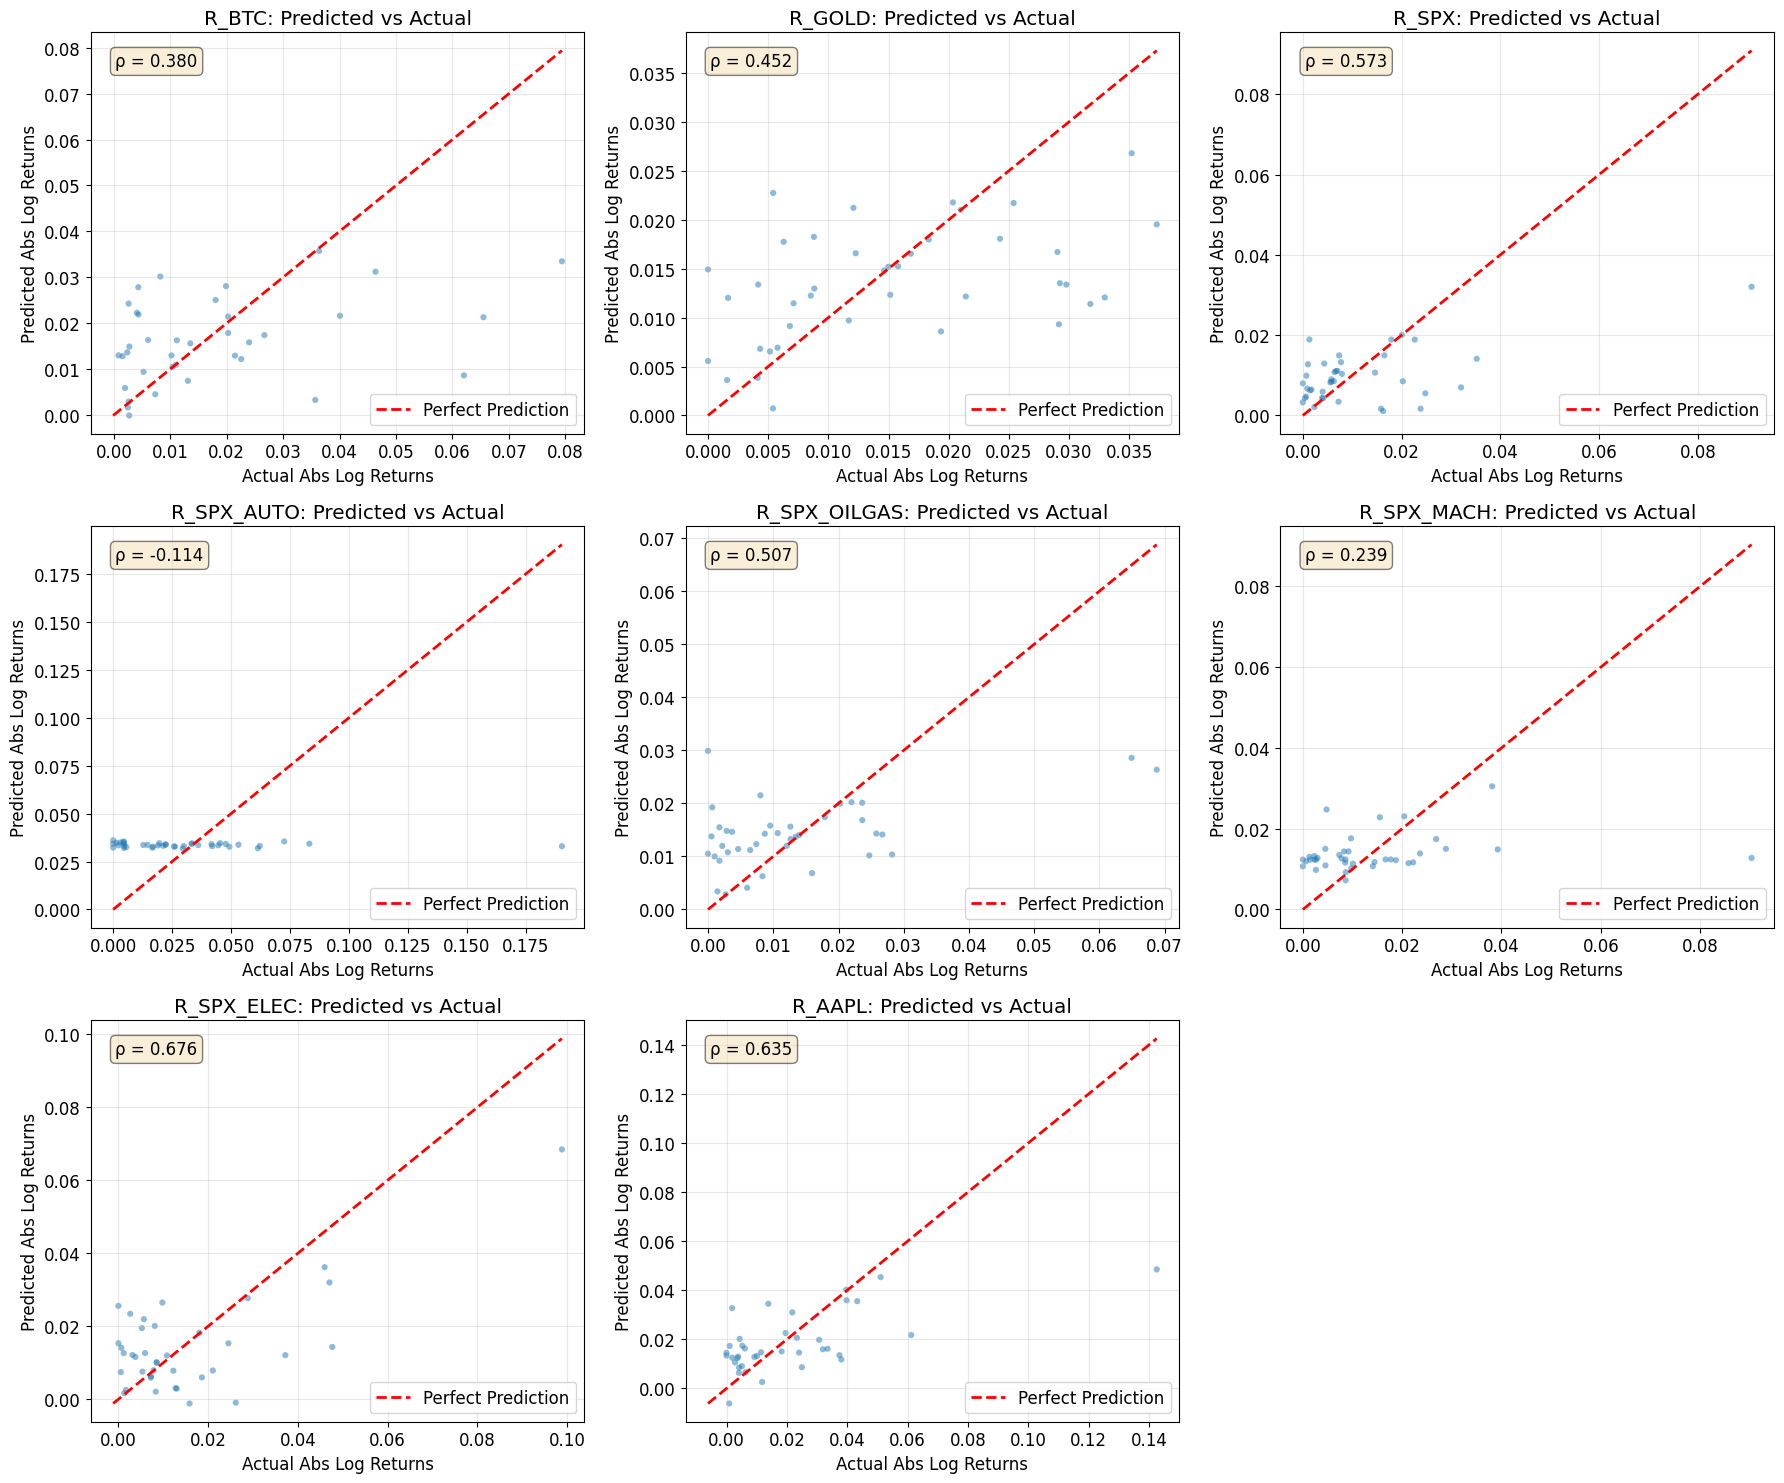


Correlation between predicted and actual:
  r_btc: 0.3805
  r_gold: 0.4516
  r_spx: 0.5725
  r_spx_auto: -0.1142
  r_spx_oilgas: 0.5068
  r_spx_mach: 0.2387
  r_spx_elec: 0.6760
  r_aapl: 0.6354


In [12]:
# Plot predicted vs actual absolute log returns
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    preds_df = oos_predictions[target]
    
    # Scatter plot
    ax.scatter(preds_df['y_true'], preds_df['y_pred'], alpha=0.5, s=20, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(preds_df['y_true'].min(), preds_df['y_pred'].min())
    max_val = max(preds_df['y_true'].max(), preds_df['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Abs Log Returns')
    ax.set_ylabel('Predicted Abs Log Returns')
    ax.set_title(f'{target.upper()}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    ax.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation between predicted and actual:")
for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    print(f"  {target}: {corr:.4f}")

In [13]:
# Display top significant emotion features
print("\n" + "="*60)
print("TOP SIGNIFICANT EMOTION FEATURES (α = 0.05)")
print("="*60)

for target in TARGET_COLS:
    print(f"\n{target}:")
    results_df = bootstrap_results[target].reset_index()  # Reset index to get feature as column
    
    # Filter emotion features only (not AR or control columns)
    emotion_mask = ~results_df['feature'].str.startswith('y_lag') & \
                   ~results_df['feature'].str.startswith('ctl_')
    
    # Check for significance column
    if 'sig_95' in results_df.columns:
        sig_mask = results_df['sig_95'] == True
        emotion_features = results_df[emotion_mask & sig_mask]
    else:
        emotion_features = results_df[emotion_mask]
    
    if len(emotion_features) > 0:
        # Sort by absolute coefficient
        emotion_features = emotion_features.copy()
        emotion_features['abs_coef'] = emotion_features['coef'].abs()
        sorted_features = emotion_features.sort_values('abs_coef', ascending=False).head(10)
        
        for _, row in sorted_features.iterrows():
            ci_low = row.get('ci_lower_95', row.get('ci_lower_0.05', np.nan))
            ci_high = row.get('ci_upper_95', row.get('ci_upper_0.05', np.nan))
            stars = row.get('stars', '')
            print(f"  {row['feature']}: {row['coef']:.6f} [{ci_low:.6f}, {ci_high:.6f}] {stars}")
    else:
        print("  No significant emotion features found.")


TOP SIGNIFICANT EMOTION FEATURES (α = 0.05)

r_btc:
  No significant emotion features found.

r_gold:
  soc_intensity_lead1: 0.010767 [0.001210, 0.016362] **

r_spx:
  No significant emotion features found.

r_spx_auto:
  No significant emotion features found.

r_spx_oilgas:
  No significant emotion features found.

r_spx_mach:
  No significant emotion features found.

r_spx_elec:
  No significant emotion features found.

r_aapl:
  No significant emotion features found.


In [14]:
# 3. SHAP Analysis
print("\n" + "="*60)
print("SHAP VALUE ANALYSIS")
print("="*60)

shap_results = {}

for target in TARGET_COLS:
    print(f"\nComputing SHAP values for {target}...")
    
    spec = emotion_results[target]['best_lags']
    y = df_clean[target]  # Keep as Series
    
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=social_df,
        controls=controls_df,
        cross=None,
        lags=spec,
    )
    
    feature_names = list(X_design.columns)
    
    # Get the model from the pipeline
    fitted_pipeline = emotion_results[target]['fitted_pipeline']
    model = fitted_pipeline.named_steps['model']
    scaler = fitted_pipeline.named_steps['scaler']
    
    # Scale the data as the model expects scaled input
    X_scaled = scaler.transform(X_design.values)
    
    # Use LinearExplainer for linear models
    explainer = shap.LinearExplainer(model, X_scaled)
    shap_values = explainer.shap_values(X_scaled)
    
    # Compute mean absolute SHAP values
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    
    shap_results[target] = {
        'shap_values': shap_values,
        'X_design': X_scaled,
        'feature_names': feature_names,
        'mean_abs_shap': dict(zip(feature_names, mean_abs_shap))
    }
    
    # Show top features
    sorted_shap = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)
    print(f"  Top 5 features by mean |SHAP|:")
    for feat, val in sorted_shap[:5]:
        print(f"    {feat}: {val:.6f}")


SHAP VALUE ANALYSIS

Computing SHAP values for r_btc...
  Top 5 features by mean |SHAP|:
    soc_ei_creator_lead2: 0.003645
    ctl_dln_eurusd_lag2: 0.003434
    soc_ei_creator_topicweighted_lead2: 0.002677
    y_lag4: 0.002372
    soc_surprise_engweighted_lag1: 0.002246

Computing SHAP values for r_gold...
  Top 5 features by mean |SHAP|:
    soc_intensity_lead1: 0.007825
    soc_intensity_engweighted_lead1: 0.007195
    soc_surprise_topicweighted_lag1: 0.005769
    soc_intensity_topicweighted_lag1: 0.005108
    soc_intensity_engweighted_topicweighted_lag1: 0.005009

Computing SHAP values for r_spx...
  Top 5 features by mean |SHAP|:
    soc_epi_signed_engweighted_lag2: 0.002663
    soc_surprise_topicweighted_lead2: 0.002654
    ctl_dy10_lag1: 0.002015
    soc_epi_engweighted_lead2: 0.001740
    soc_intensity_lag3: 0.001682

Computing SHAP values for r_spx_auto...
  Top 5 features by mean |SHAP|:
    y_lag1: 0.000000
    soc_ei_community_lag0: 0.000000
    soc_ei_community_lag1: 0.00

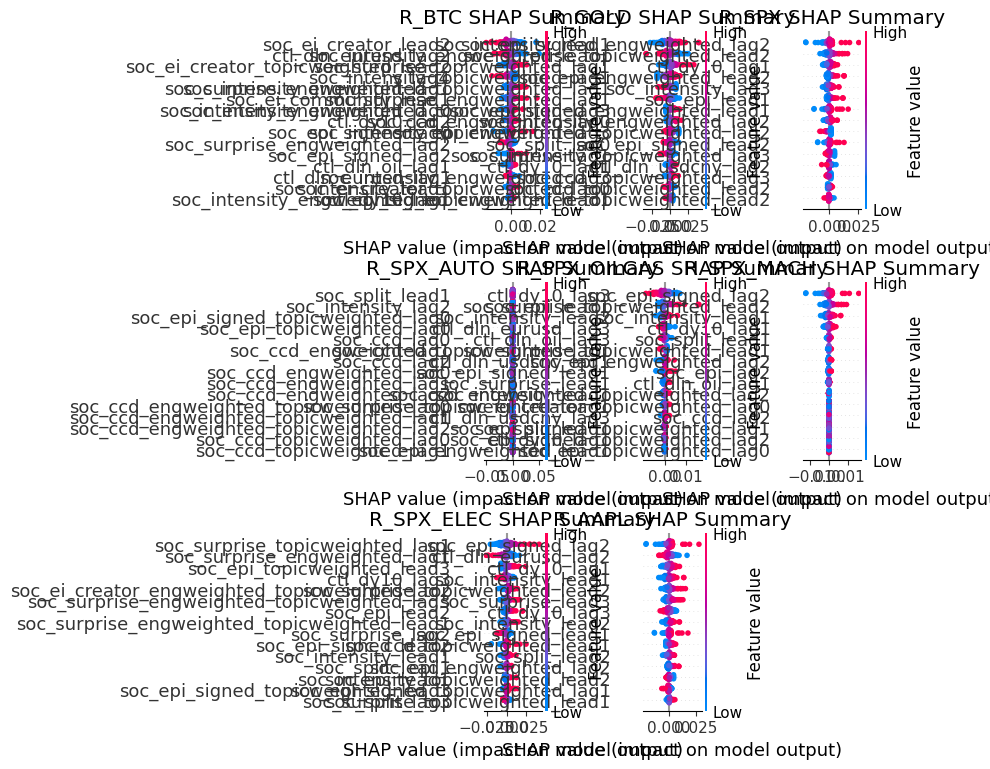

In [15]:
# SHAP Summary Plots
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 8*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_results[target]['shap_values'],
        shap_results[target]['X_design'],
        feature_names=shap_results[target]['feature_names'],
        max_display=15,
        show=False
    )
    axes[idx].set_title(f'{target.upper()} SHAP Summary')

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_emotion_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative Returns Analysis

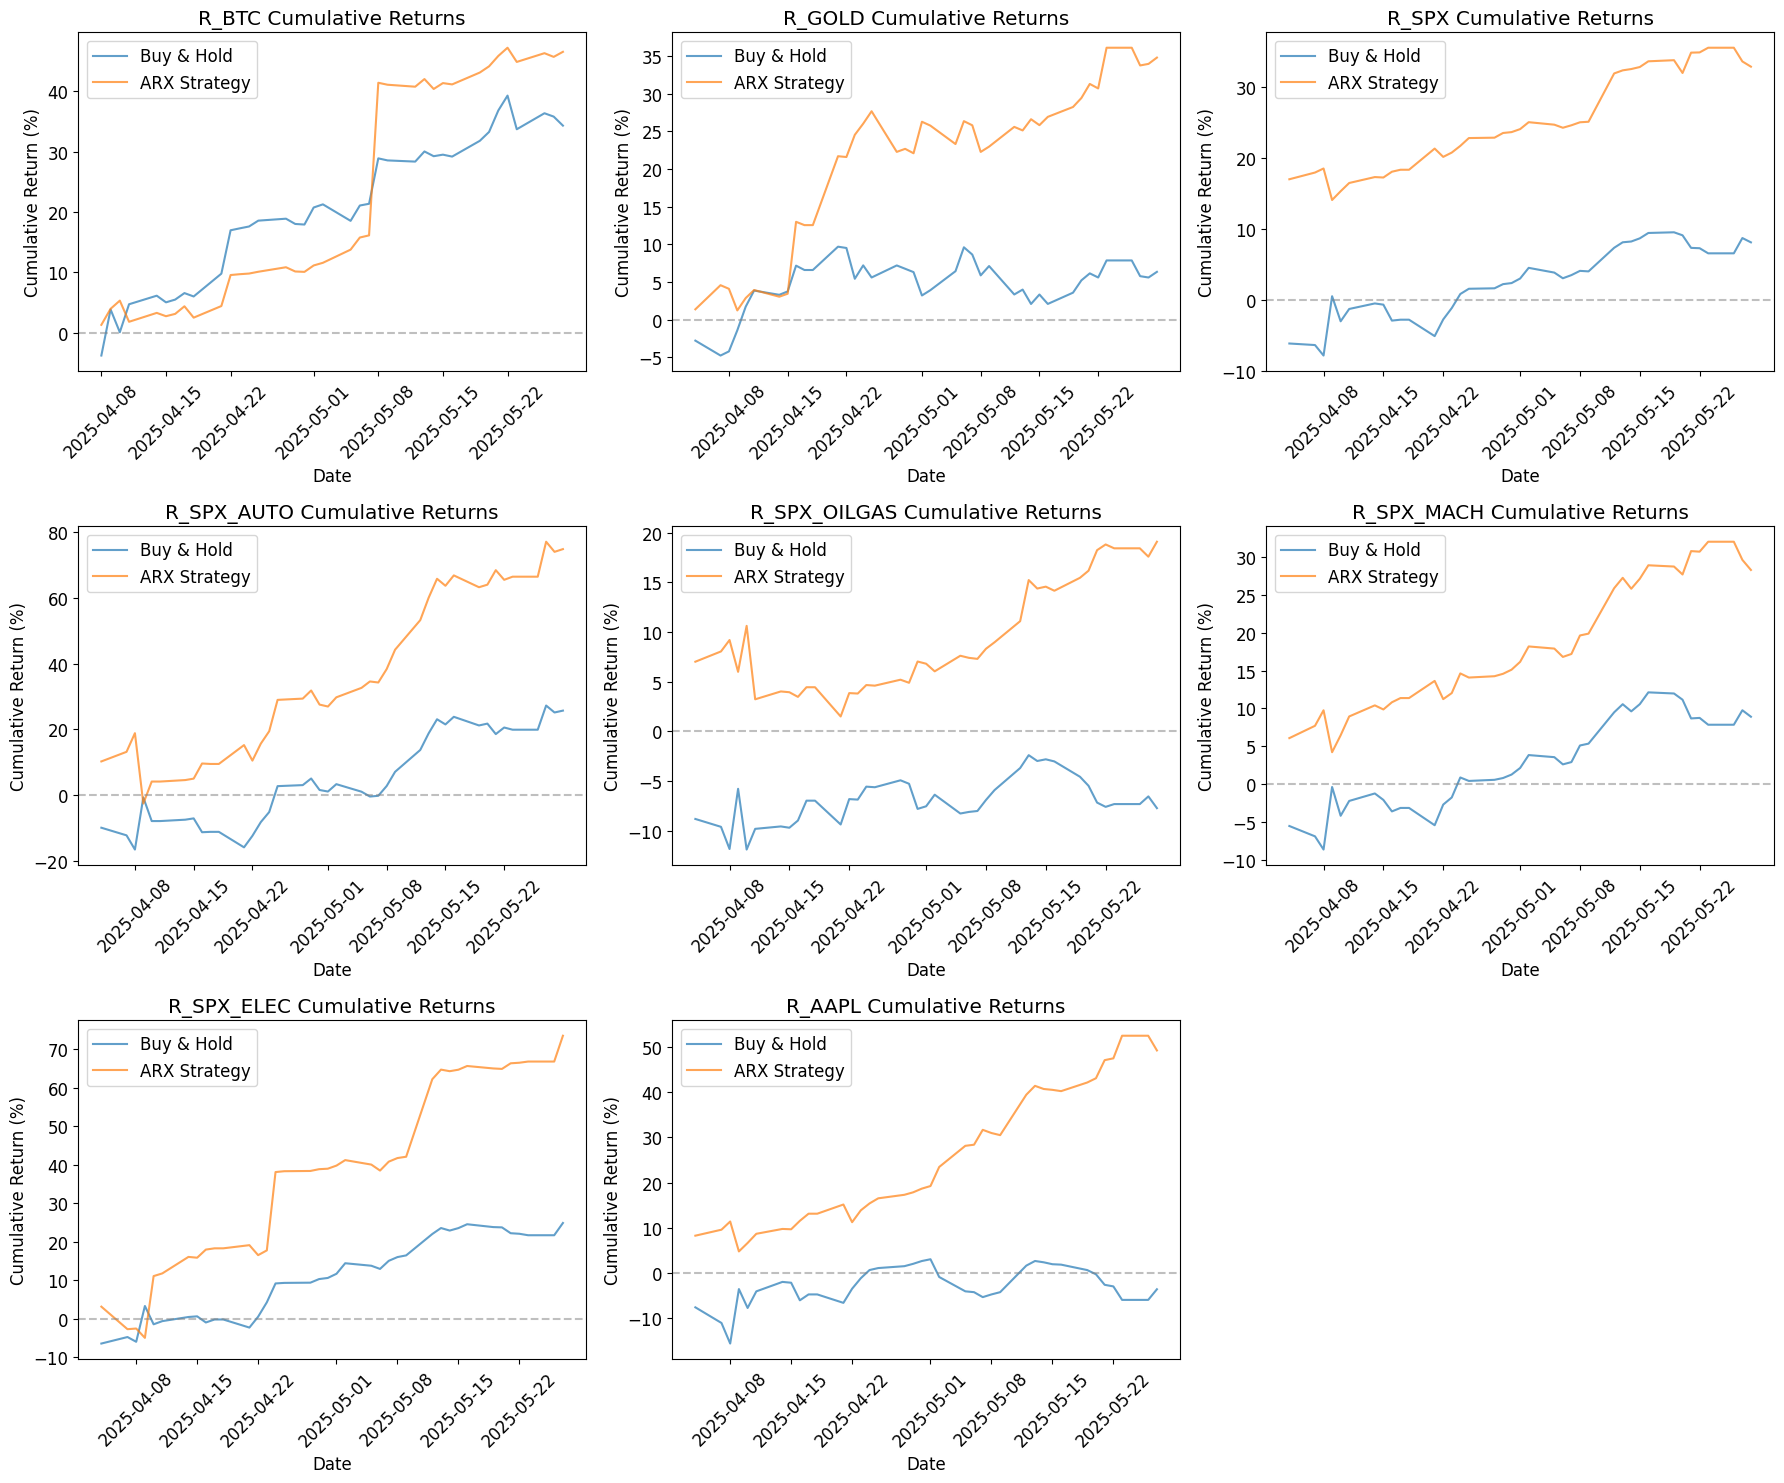


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 34.29%
    Strategy:   46.52%
  r_gold:
    Buy & Hold: 6.34%
    Strategy:   34.77%
  r_spx:
    Buy & Hold: 8.12%
    Strategy:   32.92%
  r_spx_auto:
    Buy & Hold: 25.67%
    Strategy:   74.82%
  r_spx_oilgas:
    Buy & Hold: -7.74%
    Strategy:   19.09%
  r_spx_mach:
    Buy & Hold: 8.91%
    Strategy:   28.28%
  r_spx_elec:
    Buy & Hold: 24.93%
    Strategy:   73.57%
  r_aapl:
    Buy & Hold: -3.57%
    Strategy:   49.22%

Trading Metrics Summary:

R_BTC:
  Sharpe Ratio:     4.649
  Sortino Ratio:    17.566
  Calmar Ratio:     83.187
  Max Drawdown:     -3.33%
  Win Rate:         70.3%
  Profit Factor:    5.01

R_GOLD:
  Sharpe Ratio:     4.973
  Sortino Ratio:    10.119
  Calmar Ratio:     44.887
  Max Drawdown:     -4.37%
  Win Rate:         57.5%
  Profit Factor:    2.73

R_SPX:
  Sharpe Ratio:     4.128
  Sortino Ratio:    10.322
  Calmar Ratio:     51.818
  Max Drawdown:     -3.75%
  Win Rate:         74.4%
  Profit F

In [16]:
# Compute momentum-based trading strategy with volatility scaling
from modules.finance.evaluation.trading_metrics import (
    generate_volatility_scaled_positions,
    compute_trading_metrics
)

cumulative_returns = {}
trading_metrics_all = {}

n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Get asset name
    asset = target.replace('r_', '')
    
    # Get momentum signal (5-day primary) and convert to ±1
    momentum_col = f'momentum_5d_{asset}'
    if momentum_col not in df_clean.columns:
        print(f"Warning: {momentum_col} not found, using sign of predictions")
        momentum_signal = np.sign(preds_df['y_pred'].values)
    else:
        # Align momentum with prediction dates and convert to directional signal
        momentum_values = df_clean.loc[preds_df.index, momentum_col].values
        momentum_signal = np.sign(momentum_values)  # Convert to ±1
    
    # Get signed actual returns (MUST use signed column, not y_true which is absolute)
    signed_col = f'r_{asset}_signed'
    if signed_col in df_clean.columns:
        actual_signed_returns = df_clean.loc[preds_df.index, signed_col].values
    else:
        # Fallback: convert absolute returns to signed using momentum
        print(f"Warning: {signed_col} not found, reconstructing from absolute returns")
        actual_signed_returns = preds_df['y_true'].values * momentum_signal
    
    # Generate volatility-scaled positions
    # y_pred contains predicted volatility (absolute returns), use for inverse vol weighting
    predicted_volatility = preds_df['y_pred'].values
    positions = generate_volatility_scaled_positions(
        momentum_signals=momentum_signal,
        predicted_volatility=predicted_volatility,
        percentile_cap=95,
        percentile_floor=5
    )
    
    # Strategy returns (position * actual signed return)
    strategy_returns = positions * actual_signed_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_signed_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Compute trading metrics
    trading_metrics = compute_trading_metrics(
        strategy_returns=strategy_returns,
        buy_hold_returns=actual_signed_returns
    )
    trading_metrics_all[target] = trading_metrics
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='ARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_index_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    Strategy:   {data['final_strategy']*100:.2f}%")

print("\nTrading Metrics Summary:")
for target, metrics in trading_metrics_all.items():
    print(f"\n{target.upper()}:")
    print(f"  Sharpe Ratio:     {metrics['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:    {metrics['sortino_ratio']:.3f}")
    print(f"  Calmar Ratio:     {metrics['calmar_ratio']:.3f}")
    print(f"  Max Drawdown:     {metrics['max_drawdown']*100:.2f}%")
    print(f"  Win Rate:         {metrics['win_rate']*100:.1f}%")
    print(f"  Profit Factor:    {metrics['profit_factor']:.2f}")

## Save Results

In [17]:
# Save metrics
metrics_output = []
for target in TARGET_COLS:
    spec = emotion_results[target]['best_lags']
    cv = emotion_results[target]
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'ARX_emotion',
        'p': spec.ar_p,
        'q_control': spec.q_controls,
        'q_ei': spec.q_ei,
        'q_epi': spec.q_epi,
        'q_epi_signed': spec.q_epi_signed,
        'q_ccd': spec.q_ccd,
        'q_intensity': spec.q_intensity,
        'q_surprise': spec.q_surprise,
        'q_split': spec.q_split,
        'f_ei': spec.f_ei,
        'f_epi': spec.f_epi,
        'f_epi_signed': spec.f_epi_signed,
        'f_ccd': spec.f_ccd,
        'f_intensity': spec.f_intensity,
        'f_surprise': spec.f_surprise,
        'f_split': spec.f_split,
        'cv_mae': cv['best_score_mae'],
        'cv_rmse': cv['best_score_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

metrics_output_df = pd.DataFrame(metrics_output)
metrics_output_df.to_csv(OUTPUT_DIR / 'arx_emotion_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'arx_emotion_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'arx_emotion_predictions_{target}.csv')
print(f"Saved predictions to {OUTPUT_DIR}")

# Save bootstrap results (bootstrap_results is now a DataFrame per target)
bootstrap_output = []
for target in TARGET_COLS:
    results_df = bootstrap_results[target].reset_index()
    for _, row in results_df.iterrows():
        bootstrap_output.append({
            'asset': target,
            'feature': row['feature'],
            'coef': row['coef'],
            'se': row.get('se', np.nan),
            'boot_mean': row.get('boot_mean', np.nan),
            'ci_lower_99': row.get('ci_lower_99', np.nan),
            'ci_upper_99': row.get('ci_upper_99', np.nan),
            'sig_99': row.get('sig_99', np.nan),
            'ci_lower_95': row.get('ci_lower_95', np.nan),
            'ci_upper_95': row.get('ci_upper_95', np.nan),
            'sig_95': row.get('sig_95', np.nan),
            'ci_lower_90': row.get('ci_lower_90', np.nan),
            'ci_upper_90': row.get('ci_upper_90', np.nan),
            'sig_90': row.get('sig_90', np.nan),
        })

bootstrap_df = pd.DataFrame(bootstrap_output)
bootstrap_df.to_csv(OUTPUT_DIR / 'arx_emotion_bootstrap.csv', index=False)
print(f"Saved bootstrap results to {OUTPUT_DIR / 'arx_emotion_bootstrap.csv'}")

# Save SHAP results summary
shap_output = []
for target in TARGET_COLS:
    for feat, val in shap_results[target]['mean_abs_shap'].items():
        shap_output.append({
            'asset': target,
            'feature': feat,
            'mean_abs_shap': val
        })

shap_df = pd.DataFrame(shap_output)
shap_df.to_csv(OUTPUT_DIR / 'arx_emotion_shap.csv', index=False)
print(f"Saved SHAP results to {OUTPUT_DIR / 'arx_emotion_shap.csv'}")

print("\n✅ All emotion-enhanced ARX results saved successfully!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_metrics.csv
Saved predictions to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim
Saved bootstrap results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_bootstrap.csv
Saved SHAP results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_emotion_shap.csv

✅ All emotion-enhanced ARX results saved successfully!
